In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
employee_data = pd.read_csv('../preprocessed_data/clean_data_01.csv')


In [4]:
employee_data.shape[1] - 2

26

In [5]:

X = employee_data.drop('Attrition', axis=1)
y = employee_data['Attrition']

In [6]:
ordered_categorical_features = [
    'Education', 'JobLevel', 'StockOptionLevel', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating'
]

unordered_categorical_features = X.select_dtypes(include=['object']).columns
continuous_features = X.select_dtypes(include=['float64', 'int64']).columns.difference(ordered_categorical_features)

In [7]:
assert len(ordered_categorical_features)+len(continuous_features) + len(unordered_categorical_features) == (employee_data.shape[1]-1)

In [8]:
scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()
encoder = OneHotEncoder(drop='first', sparse_output=False)

In [9]:
X_continuous = scaler.fit_transform(X[continuous_features])
X_ordered_categorical = ordinal_encoder.fit_transform(X[ordered_categorical_features])
X_categorical = encoder.fit_transform(X[unordered_categorical_features])

In [10]:
X_preprocessed = np.hstack((X_continuous,X_ordered_categorical, X_categorical))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.3, random_state=35, stratify=y)

In [12]:
#In order to handle imbalance dataset, we will use SMOTE technique for balancing the data.
smote = SMOTE(random_state=35)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [13]:
classifiers = {
    'RandomForest': RandomForestClassifier(random_state=35),
    'GradientBoosting': GradientBoostingClassifier(random_state=35),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=35),
    'SVC': SVC(random_state=35),
    'KNeighbors': KNeighborsClassifier(),
    'DecisionTree': DecisionTreeClassifier(random_state=35)
}

In [14]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=35)
model_performance = {}

In [15]:
def get_model_performance(model_name,model,X_resampled, y_resampled, X_test, y_test):
    model.fit(X_resampled, y_resampled)
    y_train_pred = model.predict(X_resampled)
    y_test_pred = model.predict(X_test)
    
    print(f'Model performance for {model_name}')
    print(f'Training Accuracy: {accuracy_score(y_resampled, y_train_pred):.2f}')
    print('Training Classification Report:')
    print(classification_report(y_resampled, y_train_pred))

    print(f'Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}')
    print('Test Classification Report:')
    print(classification_report(y_test, y_test_pred))
    print('----------------------------------------------------------------')
    

In [16]:
for model_name, model in classifiers.items():
    scores = cross_val_score(model, X_resampled, y_resampled, cv=cv, scoring='accuracy')
    model_performance[model_name] = scores.mean()
    print(f'{model_name}: {scores.mean():.4f} (+/- {scores.std():.4f})')
    print('----------------------------------------------------------------')
    get_model_performance(model_name,model,X_resampled, y_resampled, X_test, y_test)

RandomForest: 0.9923 (+/- 0.0021)
----------------------------------------------------------------
Model performance for RandomForest
Training Accuracy: 1.00
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2524
           1       1.00      1.00      1.00      2524

    accuracy                           1.00      5048
   macro avg       1.00      1.00      1.00      5048
weighted avg       1.00      1.00      1.00      5048

Test Accuracy: 0.97
Test Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1081
           1       0.98      0.83      0.90       209

    accuracy                           0.97      1290
   macro avg       0.98      0.91      0.94      1290
weighted avg       0.97      0.97      0.97      1290

----------------------------------------------------------------
GradientBoosting: 0.9261 (+/- 0.0116)
-----

In [17]:
best_model_name = max(model_performance, key=model_performance.get)
best_model = classifiers[best_model_name]

print(f'\nBest model: {best_model_name} with accuracy: {model_performance[best_model_name]:.4f}')


Best model: RandomForest with accuracy: 0.9923


Giving the report that RandomForest performance slightly better in training data than in test data is possible that is overfitting. We can apply GridSearch technique to tune hyperparameters.

In [18]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=35), param_grid=param_grid, cv=10, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_resampled, y_resampled)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters: {best_params}')
print(f'Best model: {best_model}')


y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_report = classification_report(y_test, y_test_pred)

print(f'Test Accuracy of Best Model: {test_accuracy:.2f}')
print('Test Classification Report of Best Model:')
print(test_report)


Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best model: RandomForestClassifier(max_depth=20, n_estimators=200, random_state=35)
Test Accuracy of Best Model: 0.97
Test Classification Report of Best Model:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1081
           1       0.98      0.82      0.90       209

    accuracy                           0.97      1290
   macro avg       0.97      0.91      0.94      1290
weighted avg       0.97      0.97      0.97      1290



                              Feature  Importance
11            mean_daily_worked_hours    0.104493
7                      YearsAtCompany    0.063818
40               MaritalStatus_Single    0.059100
5                   TotalWorkingYears    0.058650
0                                 Age    0.053833
9                YearsWithCurrManager    0.043995
17            EnvironmentSatisfaction    0.039644
2               MonthlyIncome_Squared    0.038116
16                    JobSatisfaction    0.036416
1            DistanceFromHome_Squared    0.035651
4                   PercentSalaryHike    0.034003
6               TrainingTimesLastYear    0.033059
3                  NumCompaniesWorked    0.030603
21   BusinessTravel_Travel_Frequently    0.029774
8             YearsSinceLastPromotion    0.025851
39              MaritalStatus_Married    0.025255
18                    WorkLifeBalance    0.023828
13                          Education    0.021911
19                     JobInvolvement    0.021676


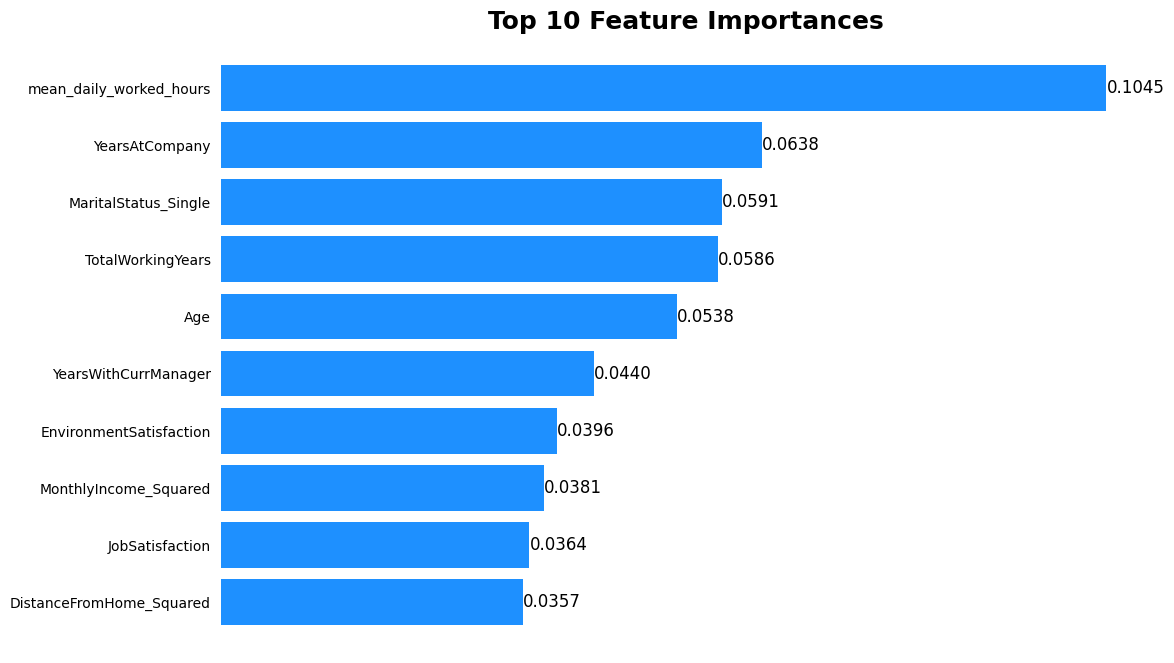

In [19]:
feature_importances = best_model.feature_importances_
continuous_feature_names = continuous_features.tolist()
ordered_categorical_feature_names = ordered_categorical_features
unordered_categorical_feature_names = encoder.get_feature_names_out(unordered_categorical_features)
all_feature_names = continuous_feature_names + list(ordered_categorical_feature_names) + list(unordered_categorical_feature_names)

feature_importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

top_features_df = feature_importance_df.head(10)
plt.figure(figsize=(12, 8))
bars = plt.barh(top_features_df['Feature'], top_features_df['Importance'], color='dodgerblue')

plt.xlabel('')
plt.ylabel('')

plt.title('Top 10 Feature Importances', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

plt.gca().tick_params(axis='y', which='both', left=False, right=False, labelleft=True)
plt.gca().tick_params(axis='x', which='both', top=False, bottom=False, labelbottom=False)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, 
             f'{bar.get_width():.4f}', va='center', fontsize=12, color='black')

plt.show()


In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame with the features
X = employee_data[['mean_daily_worked_hours', 'Age', 'TotalWorkingYears', 'MonthlyIncome_Squared', 'YearsAtCompany', 'DistanceFromHome_Squared', 'PercentSalaryHike', 'YearsWithCurrManager', 'NumCompaniesWorked', 'average_entry_time']]

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

                    Feature        VIF
0   mean_daily_worked_hours   1.003455
1                       Age   1.994088
2         TotalWorkingYears   3.117343
3     MonthlyIncome_Squared   1.470886
4            YearsAtCompany   3.468294
5  DistanceFromHome_Squared   1.002710
6         PercentSalaryHike   1.005918
7      YearsWithCurrManager   2.461734
8        NumCompaniesWorked   1.240217
9        average_entry_time  73.915703


In [21]:
#Testing high VIF features
ordered_categorical_features = [
    'Education', 'JobLevel', 'StockOptionLevel', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating'
]

unordered_categorical_features = employee_data.select_dtypes(include=['object']).columns
continuous_features = employee_data.select_dtypes(include=['float64', 'int64']).columns.difference(ordered_categorical_features)
continuous_features = continuous_features.drop('Attrition')

scaler = StandardScaler()
ordinal_encoder = OrdinalEncoder()
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_continuous = scaler.fit_transform(employee_data[continuous_features])
X_ordered_categorical = ordinal_encoder.fit_transform(employee_data[ordered_categorical_features])
X_categorical = encoder.fit_transform(employee_data[unordered_categorical_features])

X_preprocessed = np.hstack((X_continuous, X_ordered_categorical, X_categorical))

vif_data = pd.DataFrame()
all_feature_names = continuous_features.tolist() + list(ordered_categorical_features) + list(encoder.get_feature_names_out(unordered_categorical_features))
vif_data["Feature"] = all_feature_names
vif_data["VIF"] = [variance_inflation_factor(X_preprocessed, i) for i in range(X_preprocessed.shape[1])]

high_vif_features = vif_data[vif_data["VIF"] > 10]["Feature"].tolist()
high_vif_indices = [all_feature_names.index(feature) for feature in high_vif_features]

X_preprocessed_reduced = np.delete(X_preprocessed, high_vif_indices, axis=1)

remaining_feature_names = [feature for feature in all_feature_names if feature not in high_vif_features]

vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = remaining_feature_names
vif_data_reduced["VIF"] = [variance_inflation_factor(X_preprocessed_reduced, i) for i in range(X_preprocessed_reduced.shape[1])]

print(vif_data_reduced)



                             Feature       VIF
0                                Age  2.040496
1           DistanceFromHome_Squared  1.014700
2              MonthlyIncome_Squared  1.028882
3                 NumCompaniesWorked  1.262807
4                  PercentSalaryHike  2.563030
5                  TotalWorkingYears  3.157416
6              TrainingTimesLastYear  1.025592
7                     YearsAtCompany  4.023971
8            YearsSinceLastPromotion  1.661024
9               YearsWithCurrManager  2.522778
10                average_entry_time  1.007293
11           mean_daily_worked_hours  1.083052
12                    yearly_absents  1.069738
13                         Education  4.247682
14                          JobLevel  1.936113
15                  StockOptionLevel  1.895774
16                   JobSatisfaction  3.338176
17           EnvironmentSatisfaction  3.308590
18                   WorkLifeBalance  6.344320
19                    JobInvolvement  6.164959
20           